In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from scipy.optimize import fsolve
from math import exp
from scipy.optimize import root_scalar
from scipy.special import lambertw

plt.rcParams['font.family'] = 'palatino'
plt.rcParams['font.size'] = 12
plt.rcParams['mathtext.fontset'] = 'stix'

In [2]:
# define your two hex colors
hex_start = "#fa6100"   # example: blue
hex_end   = "#1461f0"   # example: red

# create continuous colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap",
    [hex_start, hex_end]
)

labelsize = 20
ticksize = 15
legendsize = 15

# The main equation

In [3]:
import numpy as np
from math import exp
from scipy.optimize import brentq

def f(r, alpha, beta): # The big "master" equation in dimensionless units
    # r: lambda/lambda0
    # alpha: ag*lambda_0
    # beta: (an-ag)*lambda_0
    return (r**2
            - exp((1 - r) * alpha) * (1 - exp(-beta * r) * (1 + beta * r)))

def find_roots(alpha, beta, rmin=0.0, rmax=1.01, ngrid=2000, tol=1e-8): # Returns the r that solces the master equation f(...)
    """
    Find roots of f(r, alpha, beta)=0 in (rmin, rmax)

    Parameters
    ----------
    alpha, beta : float
    rmin, rmax : float
        Search interval (default 0 to 1.01)
    ngrid : int
        Grid resolution
    tol : float
        Root acceptance tolerance
    """

    # avoid exact endpoints
    xs = np.linspace(rmin, rmax, ngrid + 1)
    xs[0] = np.nextafter(rmin, rmax)
    xs[-1] = np.nextafter(rmax, rmin)

    ys = np.array([f(x, alpha, beta) for x in xs])

    roots = []

    # 1) sign-change brackets
    for i in range(len(xs) - 1):
        a, b = xs[i], xs[i + 1]
        fa, fb = ys[i], ys[i + 1]

        if np.isnan(fa) or np.isnan(fb) or np.isinf(fa) or np.isinf(fb):
            continue

        if fa == 0.0:
            roots.append(a)

        elif fb == 0.0:
            roots.append(b)

        elif fa * fb < 0:
            try:
                r = brentq(f, a, b, args=(alpha, beta),
                           xtol=1e-14, rtol=1e-12, maxiter=200)
                roots.append(r)
            except ValueError:
                pass

    # 2) near-zero detection
    absys = np.abs(ys)
    near_idx = np.where(absys < tol)[0]

    for idx in near_idx:
        x0 = xs[idx]

        for k in [1, 2, 5, 10]:
            a = max(rmin, x0 - k / ngrid)
            b = min(rmax, x0 + k / ngrid)

            fa, fb = f(a, alpha, beta), f(b, alpha, beta)

            if fa * fb < 0:
                try:
                    r = brentq(f, a, b, args=(alpha, beta),
                               xtol=1e-14, rtol=1e-12, maxiter=200)
                    roots.append(r)
                except ValueError:
                    pass
                break

    # deduplicate
    roots = sorted(roots)
    merged = []

    for r in roots:
        if not merged or abs(r - merged[-1]) > tol:
            merged.append(r)

    # final verification
    good = []
    for r in merged:
        if rmin < r < rmax and abs(f(r, alpha, beta)) < tol:
            good.append(r)

    return good

In [4]:
def Alpha(ag,lam0): 
    return ag*lam0

def Beta(alpha,rp): # rp = p/pn
    return np.sqrt(2)*np.exp(-alpha/2)*np.sqrt(rp)

def K(p,v):
    return np.sqrt(2*np.pi*p*v**2)

def exponential(Lamb,t):
    return Lamb*np.exp(-Lamb*t)

def area_contribution(Lamb, v, ag, an, tvals):
    if ag == 0 and an == np.inf: # The null model
        areas = np.pi*( v * tvals )**2
    else:
        tvals_capped = np.where(tvals > an, an, tvals) # Cap at an
        tau = tvals_capped - ag
        tau_pos = np.where(tau < 0, 0, tau)
        areas = np.pi*( v * tau_pos )**2
        areas[areas < 0] = 0
    return exponential(Lamb,tvals) * areas

def birthrate_contribution(Lamb, v, ag, an, p, tvals):
    k = K(p, v)
    if ag == 0 and an == np.inf: # The null model
        return exponential(Lamb, tvals) * k**2 * tvals
    else:
        tvals_capped = np.where(tvals > an, an, tvals)  # Cap at an
        tau = tvals_capped - ag
        tau_pos = np.where(tau < 0, 0, tau)
        return exponential(Lamb, tvals) * k**2 * tau_pos


def Lamb0(ag, k):
    """
    Compute lambda_0 = (2/ag) * W((ag/2)*k)

    Parameters
    ----------
    ag : float or array
    k : float or array  (k = sqrt(2*pi*p*v^2))
    branch : int
        Lambert W branch (default 0 = principal branch)

    Returns
    -------
    float or array (real part)
    """
    if ag == 0:
        return k
    else:
        z = (ag/2) * k
        return (2/ag) * lambertw(z, 0).real

def Lamb0_check(k,alpha): # For consistency check
    return k*np.exp(-alpha/2)

def Integral(lamb,ag,an):
    tau_n = an-ag
    factor1 = np.exp(-lamb*ag)/lamb**2
    if an == np.inf:
        return factor1
    else:
        factor2 = 1-np.exp(-lamb*tau_n)*(1+lamb*tau_n)
        return factor1*factor2

def P(v,lamb,ag,an):
    return 1/(2*np.pi*v**2*Integral(lamb,ag,an))

In [5]:
alpha = 2.0
beta = 5.0
roots = find_roots(alpha, beta)
print("roots in (0,1):", roots)
for r in roots:
    print(r, "residual:", f(r, alpha, beta))

roots in (0,1): [5e-324, 0.9892288184419368]
5e-324 residual: 0.0
0.9892288184419368 residual: -1.1102230246251565e-16


# The simple graphs

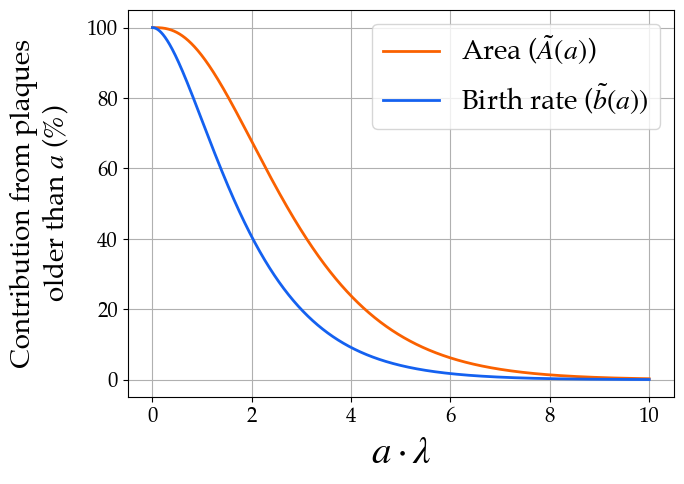

In [6]:
plot_ccdf = True  # True → CCDF, False → PDF

v       = 1
an      = np.inf
ag      = 0
Lamb    = 0.25
p       = P(v,Lamb,ag,an)
k       = K(p,v)
mean_A = 1/p
mean_b = k**2/Lamb

a_vals = np.linspace(0, 10 / Lamb, 5000)
da     = a_vals[1] - a_vals[0]

y_area  = area_contribution(Lamb, v, ag, an, a_vals)
y_birth = birthrate_contribution(Lamb, v, ag, an, p, a_vals)


if plot_ccdf:
    y_plot_area  = 1 - np.cumsum(y_area)  * da / mean_A
    y_plot_birth = 1 - np.cumsum(y_birth) * da / mean_b
    ylabel = "Contribution from plaques\nolder than $a$ (%)"
else:
    y_plot_area  = y_area  / mean_A
    y_plot_birth = y_birth / mean_b
    ylabel = r"$\tilde{A}$" if not plot_ccdf else ""

fig, ax = plt.subplots(figsize=(7, 5))

a_vals_dimless = a_vals * Lamb
ax.plot(a_vals_dimless, y_plot_area*100,  color=hex_start, lw=2, label=r"Area ($\tilde{A}(a)$)")
ax.plot(a_vals_dimless, y_plot_birth*100, color=hex_end,   lw=2, label=r"Birth rate ($\tilde{b}(a))$")
ax.grid()
ax.set_ylabel(ylabel, fontsize=labelsize, labelpad=10)
ax.set_xlabel(r"$a\cdot\lambda$", fontsize=labelsize+8)
ax.tick_params(labelsize=ticksize)
ax.legend(fontsize=legendsize+5)

plt.tight_layout()
plt.show()

In [7]:
def pick_root(roots, which="smallest"):
    if not roots:
        return np.nan
    if which == "smallest":
        return roots[0]
    if which == "largest":
        return roots[-1]
    if which == "middle":
        return roots[len(roots)//2]
    raise ValueError("unknown which")

Lamb = 0.25
ag = 0
alpha_vals = ag * Lamb
num_rp_vals = 100
rp_vals = np.linspace(1,16,100)
r_vals = np.zeros(num_rp_vals)
for i,rp in enumerate(rp_vals):
    beta = Beta(ag, rp)
    roots = find_roots(ag, beta)   # <-- list
    r_vals[i] = pick_root(roots, which="largest")

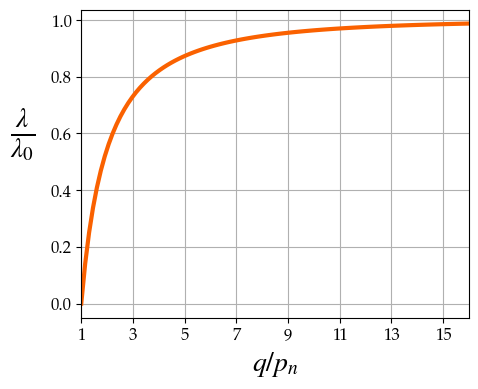

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))

colors = cmap(np.linspace(0, 1, len(r_vals)))

ax.plot(rp_vals, r_vals, color=hex_start, linewidth=3)

ax.set_xlabel(r"$q/p_n$", fontsize=labelsize)
ax.set_ylabel(r"$\frac{\lambda}{\lambda_0}$", rotation=0, fontsize=labelsize+8, labelpad=20)
ax.set_xlim(1, max(rp_vals))
#ax.axhline(1, ls="--", color="k", alpha=0.4, zorder=0)
ax.grid()
ax.set_xticks([1,3,5,7,9,11,13,15])

#ax.legend(fontsize=legendsize, loc="lower right", framealpha=0.8)
plt.show()

In [9]:
def pick_root(roots, which="smallest"):
    if not roots:
        return np.nan
    if which == "smallest":
        return roots[0]
    if which == "largest":
        return roots[-1]
    if which == "middle":
        return roots[len(roots)//2]
    raise ValueError("unknown which")

Lamb = 0.25
ag_vals = np.array([0,6,16])
p_IAV = 0.075
pn_IAV = 5*1e-3
rp_IAV = p_IAV/pn_IAV
p_WT = 0.54
pn_WT = 1e-4
rp_WT = p_WT/pn_WT
alpha_vals = ag_vals * Lamb
num_rp_vals = 100
rp_vals = np.logspace(np.log(1.01), np.log(10000), num_rp_vals,base = np.exp(1))
num_alpha_vals = len(alpha_vals)
r_vals = np.zeros((num_alpha_vals,num_rp_vals))
for i,alpha in enumerate(alpha_vals):
    for j, rp in enumerate(rp_vals):
        beta = Beta(alpha, rp)
        roots = find_roots(alpha, beta)   # <-- list
        r_vals[i,j] = pick_root(roots, which="largest")

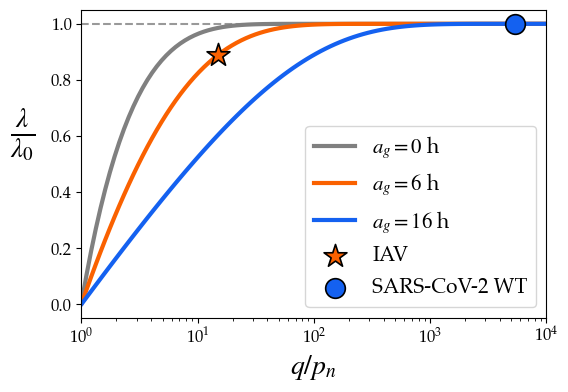

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = cmap(np.linspace(0, 1, len(r_vals)))
biological_values = True
if biological_values:
    ax.plot(rp_vals, r_vals[0], color="grey", linewidth=3, label=rf"$a_g = {ag_vals[0]}$ h")
    ax.plot(rp_vals, r_vals[1], color=colors[0], linewidth=3, label=rf"$a_g = {ag_vals[1]}$ h")
    ax.plot(rp_vals, r_vals[2], color=colors[2], linewidth=3, label=rf"$a_g = {ag_vals[2]}$ h")

    # Markers at biological rp values
    r_IAV_marker = np.interp(rp_IAV, rp_vals, r_vals[1])
    r_WT_marker  = np.interp(rp_WT,  rp_vals, r_vals[2])
    ax.scatter([rp_IAV], [r_IAV_marker], color=colors[0], s=300, marker="*",
               zorder=5, edgecolors="k", linewidths=1.2, label = "IAV")
    ax.scatter([rp_WT],  [r_WT_marker],  color=colors[2], s=200, marker="o",
               zorder=5, edgecolors="k", linewidths=1.2, label = "SARS-CoV-2 WT")
else:
    for i, row in enumerate(r_vals):
        ax.plot(rp_vals, row, color=colors[i], linewidth=3, label=rf"$\alpha = {alpha_vals[i]:.1f}$")

ax.set_xlabel(r"$q/p_n$", fontsize=labelsize)
ax.set_ylabel(r"$\frac{\lambda}{\lambda_0}$", rotation=0, fontsize=labelsize+8, labelpad=20)
ax.set_xlim(1, max(rp_vals))
ax.set_xscale("log")
ax.axhline(1, ls="--", color="k", alpha=0.4, zorder=0)

ax.legend(fontsize=legendsize, loc="lower right", framealpha=0.8)
plt.show()

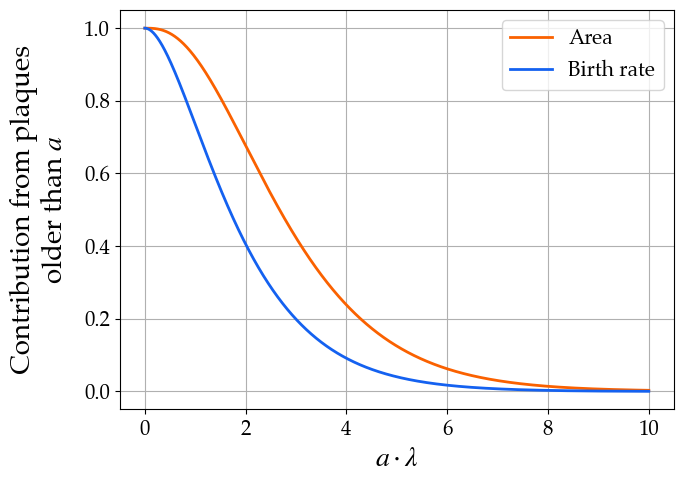

In [11]:
plot_ccdf = True  # True → CCDF, False → PDF

v  = 1
an = np.inf
ag = 0
Lamb = 0.25
p = P(v,Lamb,ag,an)
k    = K(p, v)

a_vals = np.linspace(0, 10 / Lamb, 5000)
da     = a_vals[1] - a_vals[0]

y_area  = area_contribution(Lamb, v, ag, an, a_vals)
y_birth = birthrate_contribution(Lamb, v, ag, an, p, a_vals)

if plot_ccdf:
    y_plot_area  = 1 - np.cumsum(y_area)  * da * p
    y_plot_birth = 1 - np.cumsum(y_birth) * da / (np.cumsum(y_birth)[-1] * da)
    ylabel = "Contribution from plaques\nolder than $a$"
else:
    y_plot_area  = y_area  * p
    y_plot_birth = y_birth / (np.sum(y_birth) * da)
    ylabel = r"$\tilde{A}$" if not plot_ccdf else ""

fig, ax = plt.subplots(figsize=(7, 5))

a_vals_dimless = a_vals * Lamb
ax.plot(a_vals_dimless, y_plot_area,  color=hex_start, lw=2, label="Area")
ax.plot(a_vals_dimless, y_plot_birth, color=hex_end,   lw=2, label="Birth rate")
ax.grid()
ax.set_ylabel(ylabel, fontsize=labelsize, labelpad=10)
ax.set_xlabel(r"$a\cdot\lambda$", fontsize=labelsize)
ax.tick_params(labelsize=ticksize)
ax.legend(fontsize=legendsize)

plt.tight_layout()
plt.show()

# Put in biological values

In [12]:
IAV_params = {
    "v": 1,
    "ag": 6,
    "pn": 5e-3,
    "lambda": 0.25,
    "p": 0.075
}

IAV_corrected_params = {
    "v": 1,
    "ag": 6,
    "pn": 5e-4,
    "lambda": 0.25,
}

WT_params = {
    "v": 1,
    "ag": 16,
    "pn": 1e-4,
    "lambda": 0.25,
    "p": 0.54
}

delta_params = {
    "v": 1,
    "ag": 12,
    "pn": 1e-4,
    "lambda": 0.25,
}

In [13]:
def Tau_n(v,p_n):
    if p_n > 0:
        return 1/(v*np.sqrt(np.pi*p_n))
    else:
        return np.inf

fixed_lambda = True
chosen_params = WT_params
v = chosen_params["v"]
p_n = chosen_params["pn"]
tau_n = Tau_n(v,p_n)
ag =  chosen_params["ag"]
an = tau_n + ag

if fixed_lambda:
    lamb = chosen_params["lambda"]
    p = P(v,lamb,ag,an)
else:
    p = chosen_params["p"]
    k = K(p,v)
    lamb0 = Lamb0(ag,k)
    alpha = Alpha(ag,lamb0)
    beta = (an - ag) * lamb0
    roots = find_roots(alpha, beta)
    r = pick_root(roots, which="largest")
    lamb = r * lamb0

k = K(p,v)
lamb0 = Lamb0(ag,k)
alpha = Alpha(ag,lamb0)
lamb0_check = Lamb0_check(k,alpha)

if np.isclose(lamb0,lamb0_check):
    print("Consistent lamb0 😊")
else:
    print("NB: Inconsistent lamb0! 😔 )")

print(f"p = {p:.5f}, p/pn = {p/p_n:.2f}, k = {k:.2f}/h^2, alpha = {alpha:.2f}")
print(f"lambda0 = {lamb0:.2f}/h, lambda = {lamb:.3f}/h, r = {lamb/lamb0:.7f}")
print(f"an = {an:.2f} h (should be around 72 h)")

Consistent lamb0 😊
p = 0.54310, p/pn = 5431.04, k = 1.85/h^2, alpha = 4.00
lambda0 = 0.25/h, lambda = 0.250/h, r = 0.9999981
an = 72.42 h (should be around 72 h)


In [14]:
lambda_base = 0.25
lambda_other = 0.21
np.exp((lambda_base-lambda_other)*48)

6.820958469290752

# Fixed p, varying $\lambda_0$

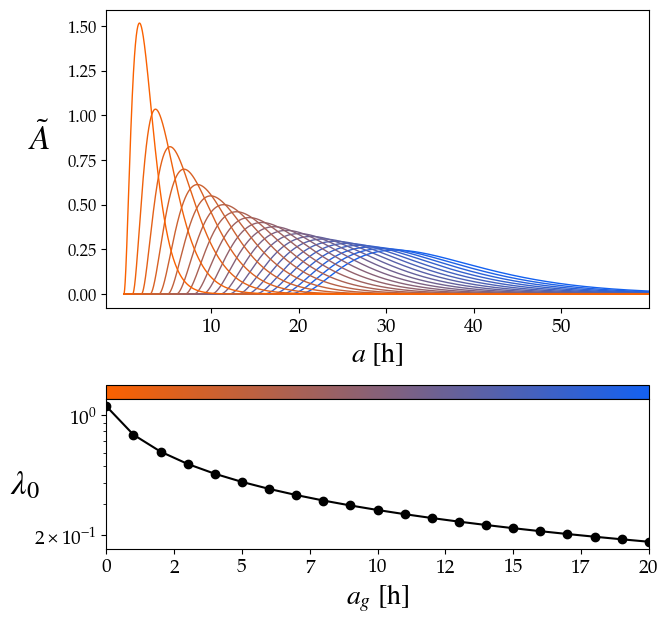

In [15]:
ticksize = 14
plot_birthrate = False  # True → birthrate contribution, False → area contribution

a_vals = np.linspace(0, 150, 10000)
ag_vals = np.linspace(0, 20, 21)
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [hex_start, hex_end])
norm = mcolors.Normalize(vmin=ag_vals.min(), vmax=ag_vals.max())
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

v = 1
#Lambd0 = 0.25 # Random value to determine a fixed p
p = 0.2
k = K(p,v)
an= np.infty

fig = plt.figure(figsize=(7, 8))
gs = gridspec.GridSpec(
    3, 1,
    height_ratios=[10, 0.5, 5],
    hspace=0.5
)
ax_main = fig.add_subplot(gs[0])
ax_cbar = fig.add_subplot(gs[1])
ax_lamb = fig.add_subplot(gs[2])

# --- Main plot ---
for i, ag in enumerate(ag_vals):
    color   = cmap(norm(ag))
    Lambd0  = Lamb0(ag, k)    
    if plot_birthrate:
        y = birthrate_contribution(Lamb=Lambd0, v=v, ag=ag, an=an, p=p, tvals=a_vals)
    else:
        y = area_contribution(Lamb=Lambd0, v=v, ag=ag, an=an, tvals=a_vals)
        integral = np.trapz(y, a_vals)
        if not np.isclose(integral*p,1,rtol=0.1):
            print(f"OBS mean area times p = {integral*p}")
    ax_main.plot(a_vals, y, color=color, alpha=1, linewidth=1, zorder=len(ag_vals) - i)

ax_main.set_xlabel(r"$a\ \mathrm{[h]}$", fontsize=labelsize)
ax_main.set_ylabel(r"$\tilde{B}$" if plot_birthrate else r"$\tilde{A}$",
                   fontsize=labelsize + 4, rotation=0, labelpad=20)
xticks = [10,20,30,40,50]
ax_main.set_xticks(xticks)
ax_main.set_xticklabels(xticks, fontsize=ticksize)
ax_main.set_xlim(-2,60)
# ax_main.set_yscale("log")

# --- Horizontal colorbar: no ticks ---
cbar = fig.colorbar(sm, cax=ax_cbar, orientation='horizontal')
cbar.ax.xaxis.set_label_position('top')
cbar.set_ticks([])

# --- Lambda0 vs ag curve ---
Lamb_vals = np.array([Lamb0(ag, k) for ag in ag_vals])

ax_lamb.plot(ag_vals, Lamb_vals, color='black', linewidth=1.5,marker = "o")
ax_lamb.set_xlim(ag_vals.min(), ag_vals.max())
ax_lamb.set_ylabel(r"$\lambda_0$", rotation=0, fontsize=labelsize + 5)
ax_lamb.yaxis.set_label_coords(-0.15, 0.3)
ax_lamb.set_xlabel(r"$a_g\ \mathrm{[h]}$", fontsize=labelsize)
ax_lamb.tick_params(axis='x', labelsize=ticksize)
ax_lamb.tick_params(axis='y', labelsize=ticksize)
ax_lamb.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))
ax_lamb.set_yscale("log")
yticks = [2e-1,1]
ax_lamb.set_yticks(yticks)
ax_lamb.yaxis.set_minor_formatter(plt.NullFormatter())

# --- Align and close gap between colorbar and bottom curve ---
fig.canvas.draw()
pos_cbar = ax_cbar.get_position()
pos_p    = ax_lamb.get_position()
ax_lamb.set_position([pos_cbar.x0, pos_cbar.y0 - pos_p.height, pos_cbar.width, pos_p.height])

plt.show()

# Introducing pn

1.0000000000000004
1.0
1.0
1.0000000000000129
1.0000000000001148
0.9999999999997758
0.9999999999999803
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


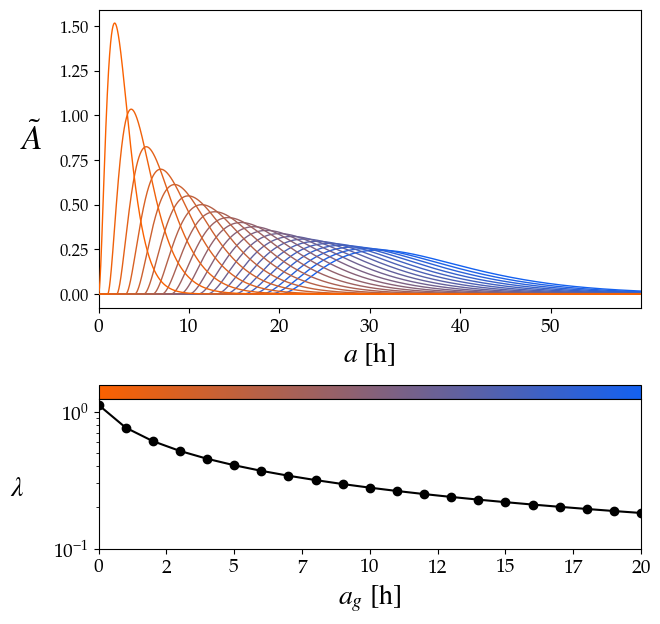

In [16]:
ticksize = 14
plot_birthrate = False  # True → birthrate contribution, False → area contribution

a_vals = np.linspace(0, 100, 100000)
ag_vals = np.linspace(0, 20, 21)
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [hex_start, hex_end])
norm = mcolors.Normalize(vmin=ag_vals.min(), vmax=ag_vals.max())
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

v = 1
p = 0.2
k = K(p,v)
tau_n = 1e9

fig = plt.figure(figsize=(7, 8))
gs = gridspec.GridSpec(
    3, 1,
    height_ratios=[10, 0.5, 5],
    hspace=0.5
)
ax_main = fig.add_subplot(gs[0])
ax_cbar = fig.add_subplot(gs[1])
ax_lamb = fig.add_subplot(gs[2])

Lamb_vals = np.zeros_like(ag_vals)

# --- Main plot ---
for i, ag in enumerate(ag_vals):
    color = cmap(norm(ag))
    Lambd0  = Lamb0(ag, k)
    alpha = ag*Lambd0
    an = ag + tau_n
    beta = tau_n*Lambd0
    r = find_roots(alpha=alpha, beta=beta)
    print(r[1])
    Lamb = r[1]*Lambd0
    Lamb_vals[i] = Lamb
    if plot_birthrate:
        y = birthrate_contribution(Lamb=Lamb, v=v, ag=ag, an=an, p=p, tvals=a_vals)
    else:
        y = area_contribution(Lamb=Lamb, v=v, ag=ag, an=an, tvals=a_vals) 
    ax_main.plot(a_vals, y, color=color, alpha=1, linewidth=1, zorder=len(ag_vals) - i)

ax_main.set_xlabel(r"$a\ \mathrm{[h]}$", fontsize=labelsize)
ax_main.set_ylabel(r"$\tilde{B}$" if plot_birthrate else r"$\tilde{A}$",
                   fontsize=labelsize + 4, rotation=0, labelpad=20)
ax_main.set_xlim(0,60)
xticks = [0,10,20,30,40,50]
ax_main.set_xticks(xticks)
ax_main.set_xticklabels(xticks, fontsize=ticksize)
#ax_main.set_yscale("log")

# --- Horizontal colorbar: no ticks ---
cbar = fig.colorbar(sm, cax=ax_cbar, orientation='horizontal')
cbar.ax.xaxis.set_label_position('top')
cbar.set_ticks([])

# --- Lambda vs ag curve ---
ax_lamb.plot(ag_vals, Lamb_vals, color='black', linewidth=1.5,marker = "o")
ax_lamb.set_xlim(ag_vals.min(), ag_vals.max())
ax_lamb.set_ylabel(r"$\lambda$", rotation=0, fontsize=labelsize)
ax_lamb.yaxis.set_label_coords(-0.15, 0.3)
ax_lamb.set_xlabel(r"$a_g\ \mathrm{[h]}$", fontsize=labelsize)
ax_lamb.tick_params(axis='x', labelsize=ticksize)
ax_lamb.tick_params(axis='y', labelsize=ticksize)
ax_lamb.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))
ax_lamb.set_yscale("log")
yticks = [1,1e-1]
ax_lamb.set_yticks(yticks)

# --- Align and close gap between colorbar and bottom curve ---
fig.canvas.draw()
pos_cbar = ax_cbar.get_position()
pos_p    = ax_lamb.get_position()
ax_lamb.set_position([pos_cbar.x0, pos_cbar.y0 - pos_p.height, pos_cbar.width, pos_p.height])

plt.show()

## Fixed $\lambda_0$, varying p

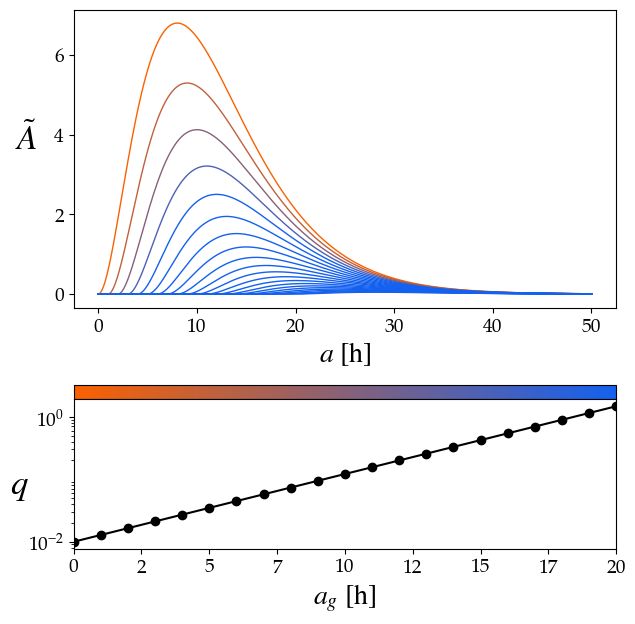

In [17]:
ag_vals = np.linspace(0, 20, 21)
a_vals = np.linspace(0, 50, 1000)
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [hex_start, hex_end])
norm = mcolors.Normalize(vmin=alpha_vals.min(), vmax=alpha_vals.max())
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

Lambd0 = 0.25
an_fixed = np.inf

fig = plt.figure(figsize=(7, 8))
gs = gridspec.GridSpec(
    3, 1,
    height_ratios=[10, 0.5, 5],
    hspace=0.5
)

ax_main = fig.add_subplot(gs[0]) 
ax_cbar = fig.add_subplot(gs[1])
ax_p    = fig.add_subplot(gs[2])

# --- Horizontal colorbar: no ticks, label on top ---
cbar = fig.colorbar(sm, cax=ax_cbar, orientation='horizontal')
#cbar.set_label(r"$\alpha$", fontsize=18, labelpad=6)
cbar.ax.xaxis.set_label_position('top')
cbar.set_ticks([])  # Remove all ticks

# --- P vs alpha curve ---
P_vals = np.zeros_like(ag_vals)
for i,ag in enumerate(ag_vals):
    p_val = P(v, Lambd0, ag, an_fixed)
    P_vals[i] = p_val
P_vals = np.array(P_vals)

# --- Main plot ---
for i, ag in enumerate(ag_vals):
    color   = cmap(norm(ag))
    an      = np.infty
    p       = P_vals[i]
    if plot_birthrate:
        y = birthrate_contribution(Lamb=Lambd0, v=v, ag=ag, an=an, p=p, tvals=a_vals)
    else:
        y = area_contribution(Lamb=Lambd0, v=v, ag=ag, an=an, tvals=a_vals)
        integral = np.trapz(y, a_vals)
        if not np.isclose(integral*p,1,rtol=0.1):
            print(f"OBS mean area times p = {integral*p}")
    ax_main.plot(a_vals, y, color=color, alpha=1, linewidth=1)

ax_main.set_ylabel(r"$\tilde{A}$", rotation=0, labelpad=20, fontsize=labelsize + 4)
ax_main.set_xlabel(r"$a\ \mathrm{[h]}$", fontsize=labelsize)
ax_main.tick_params(axis='x', labelsize=ticksize)
ax_main.tick_params(axis='y', labelsize=ticksize)

ax_p.plot(ag_vals, P_vals, color='black', linewidth=1.5,marker = "o")
ax_p.set_xlim(ag_vals.min(), ag_vals.max())
ax_p.set_yscale('log')
ax_p.set_ylabel(r"$q$", rotation=0, fontsize=labelsize + 5)
ax_p.yaxis.set_label_coords(-0.1, 0.3)
ax_p.set_xlabel(r"$a_g\ \mathrm{[h]}$", fontsize=labelsize)
ax_p.tick_params(axis='x', labelsize=ticksize)
ax_p.tick_params(axis='y', labelsize=ticksize)
ax_p.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))
yticks = [1e-2,1]
ax_p.set_yticks(yticks)

# Align axes and close the gap between colorbar and P-curve
fig.canvas.draw()
pos_cbar = ax_cbar.get_position()
pos_p    = ax_p.get_position()

# Place P-curve directly below colorbar (no gap)
ax_p.set_position([pos_cbar.x0, pos_cbar.y0 - pos_p.height, pos_cbar.width, pos_p.height])

plt.show()

In [18]:
v,p,lamb

(1, 1.4762929931911868, 0.25)

## Area on the x axis

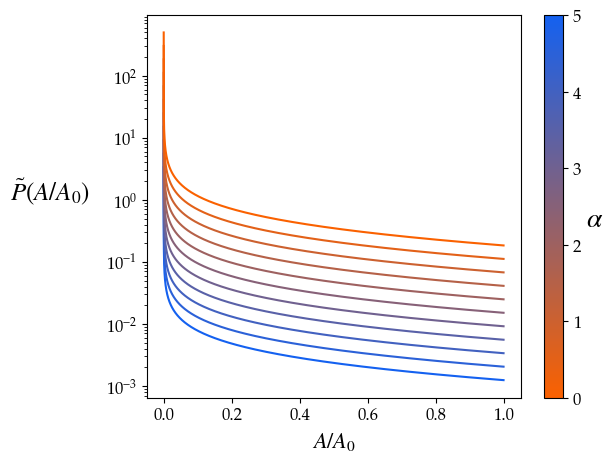

In [19]:
# Below is the area contribution as function of area, not of age

alpha_vals = np.linspace(0, 5, 11)
A0 = 1  # pi * v^2 / lambda_0^2, sets the scale
A_vals = np.linspace(1e-6, 1, 10000) * A0

cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [hex_start, hex_end])
norm = mcolors.Normalize(vmin=alpha_vals.min(), vmax=alpha_vals.max())
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig, ax = plt.subplots()

for i, alpha in enumerate(alpha_vals):
    u = A_vals / A0
    pdf = np.exp(-alpha) / (2 * np.sqrt(u)) * np.exp(-np.sqrt(u))
    ax.plot(A_vals / A0, pdf, color=cmap(norm(alpha)), zorder=len(alpha_vals) - i)

ax.set_yscale("log")
ax.set_xlabel(r"$A/A_0$", fontsize=16)
ax.set_ylabel(r"$\tilde{P}(A/A_0)$", rotation=0, labelpad=40, fontsize=18)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$\alpha$", rotation=0, fontsize=20, labelpad=10)

plt.tight_layout()
plt.show()

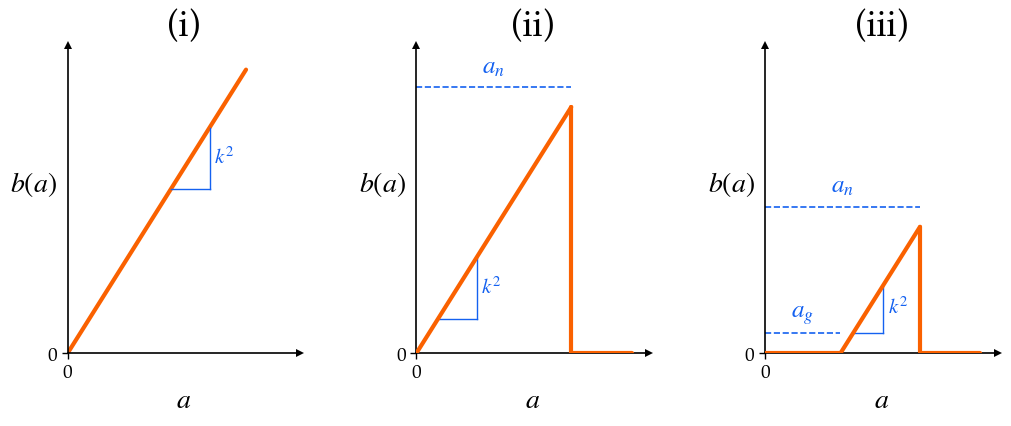

In [20]:
# ── shared parameters ─────────────────────────────────────────────────────────
k   = 1.2
a_g = 0.35
a_n = 0.72
A   = 1.0
pad = 0.08
labelsize = 20

plot2_show_an = True   # True → plot (ii) introduces a_n; False → introduces a_g

def clean_ax(ax):
    ax.set_xlim(0, A + pad)
    ax.set_ylim(0, A + pad)
    ax.set_xticks([0])
    ax.set_yticks([0])
    ax.tick_params(axis="both", length=4, width=1.0, labelsize=14)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_position(("data", 0))
    ax.spines["left"].set_position(("data", 0))
    ax.set_xlabel(r"$a$", fontsize=labelsize, labelpad=4)
    ax.set_ylabel(r"$b(a)$", fontsize=labelsize, rotation=0, labelpad=10)
    #ax.yaxis.set_label_coords(-0.06, 1.0)
    # arrowheads at axis tips
    ax.plot(A + pad, 0, ">", color="k", markersize=6,
            markeredgewidth=0, clip_on=False, zorder=5)
    ax.plot(0, A + pad, "^", color="k", markersize=6,
            markeredgewidth=0, clip_on=False, zorder=5)

def slope_indicator(ax, x0, y0, dx, color, lw=1.0):
    dy = k * dx
    ax.plot([x0, x0 + dx],      [y0, y0],      color=color, lw=lw, ls="-")
    ax.plot([x0 + dx, x0 + dx], [y0, y0 + dy], color=color, lw=lw, ls="-")
    #ax.text(x0 + dx * 0.5, y0 - 0.03, "1", ha="center", va="top",    fontsize=9,  color=color)
    ax.text(x0 + dx + 0.02, y0 + dy * 0.5, r"$k^2$",
            ha="left",   va="center", fontsize=15, color=color, fontstyle="italic")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
plt.subplots_adjust(wspace=0.5)

linewidth = 3
curve_kw = dict(color=hex_start, lw=linewidth, solid_capstyle="round")

# ── PLOT 1 ────────────────────────────────────────────────────────────────────
ax = axes[0]
clean_ax(ax)
a1 = np.linspace(0, A, 200)
b1 = k * a1
ax.plot(a1[b1 <= A], b1[b1 <= A], **curve_kw)
slope_indicator(ax, 0.48, k * 0.48, 0.18, hex_end, lw=1.0)
ax.set_title("(i)", fontsize=25)

# ── PLOT 2 ────────────────────────────────────────────────────────────────────
ax = axes[1]
clean_ax(ax)

if plot2_show_an:
    # curve: b = k*a up to a_n, then drops to 0
    b_at_an2 = k * a_n
    a2r = np.linspace(0, a_n, 200)
    ax.plot(a2r, k * a2r, **curve_kw, zorder=3)
    ax.plot([a_n, A], [0, 0], **curve_kw, zorder=3)
    ax.plot([a_n, a_n], [0, b_at_an2], **curve_kw, zorder=3)  # vertical drop

    off = b_at_an2 + 0.07
    ax.plot([0, a_n], [off, off], color=hex_end, lw=1.2, ls="--", clip_on=False)
    ax.text(a_n / 2, off + 0.025, r"$a_n$",
            ha="center", va="bottom", fontsize=18, color=hex_end)
    slope_indicator(ax, 0.10, k * 0.10, 0.18, hex_end, lw=1.0)
else:
    # curve: flat for [0, a_g], then rises with slope k
    ax.plot([0, a_g], [0, 0], **curve_kw, zorder=3)
    a2  = np.linspace(a_g, A, 200)
    b2  = k * (a2 - a_g)
    ax.plot(a2[b2 <= A], b2[b2 <= A], **curve_kw, zorder=3)

    off = 0.07
    ax.plot([0, a_g], [off, off], color=hex_end, lw=1.2, ls="--", clip_on=False)
    ax.text(a_g / 2, off + 0.025, r"$a_g$",
            ha="center", va="bottom", fontsize=18, color=hex_end)
    slope_indicator(ax, a_g + 0.10, k * 0.10, 0.16, hex_end, lw=1.0)

ax.set_title(r"(ii)", fontsize=25)

# ── PLOT 3 ────────────────────────────────────────────────────────────────────
ax = axes[2]
clean_ax(ax)
b_at_an = k * (a_n - a_g)

ax.plot([0, a_g], [0, 0], **curve_kw, zorder=3)
a3 = np.linspace(a_g, a_n, 200)
b3 = k * (a3 - a_g)
ax.plot(a3, b3, **curve_kw, zorder=3)
ax.plot([a_n, A], [0, 0], **curve_kw, zorder=3)

# discontinuity — solid vertical drop
ax.plot([a_n, a_n], [0, b_at_an], **curve_kw)

# a_g: dashed line above flat-left segment
off_g = 0.07
ax.plot([0, a_g], [off_g, off_g], color=hex_end, lw=1.2, ls="--", clip_on=False)
ax.text(a_g / 2, off_g + 0.025, r"$a_g$",
        ha="center", va="bottom", fontsize=18, color=hex_end)

# a_n: dashed line above the rising segment, centred over [a_g, a_n]
off_n = b_at_an + 0.07
ax.plot([0, a_n], [off_n, off_n], color=hex_end, lw=1.2, ls="--", clip_on=False)
ax.text(a_n / 2, off_n + 0.025, r"$a_n$",
        ha="center", va="bottom", fontsize=18, color=hex_end)

slope_indicator(ax, a_g + 0.06, k * 0.06, 0.14, hex_end, lw=1.0)
ax.set_title(r"(iii)", fontsize=25)

plt.show()

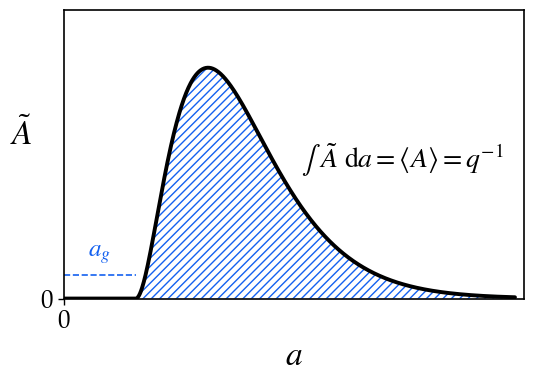

In [21]:
Lamb  = 2.5
v     = 1.0
a_g_plot   = 0.8
A     = 5
pad   = 0.10
labelsize = 20

def area_contribution_cartoon(Lamb, v, ag, tvals):
    tau     = tvals - ag
    tau_pos = np.where(tau < 0, 0, tau)
    areas   = np.pi * (v * tau_pos) ** 2
    return np.exp(-Lamb * tvals) * areas

t    = np.linspace(0, A, 800)
y    = area_contribution_cartoon(Lamb, v, a_g_plot, t)
ymax = y.max()

fig, ax = plt.subplots(figsize=(5.5, 4))

ax.set_xlim(0, A + pad)
ax.set_ylim(0, ymax * 1.25)
ax.set_xticks([0])
ax.set_yticks([0])
ax.tick_params(axis="both", length=4, width=1.0, labelsize=18)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
ax.set_xlabel(r"$a$", fontsize=labelsize+4)
ax.set_ylabel(r"$\tilde{A}$", fontsize=labelsize+4, rotation=0, labelpad=14)

# hatched fill
ax.fill_between(t, y, 0,
                facecolor="none", edgecolor=hex_end,
                hatch="////", linewidth=0.0, zorder=2)

# curve
ax.plot(t, y, color="k", lw=2.8, solid_capstyle="round", zorder=3)

# a_g_plot annotation
off_g = ymax * 0.10
ax.plot([0, a_g_plot], [off_g, off_g], color=hex_end, lw=1.2, ls="--", clip_on=False)
ax.text(a_g_plot / 2, off_g + ymax * 0.04, r"$a_g$",
        ha="center", va="bottom", fontsize=18, color=hex_end)

# textbox centred on the peak of the curve
t_peak = t[np.argmax(y)]
tb_x   = t_peak + 2.15
tb_y   = ymax * 0.6
ax.text(tb_x, tb_y, r"$\int\ \tilde{A}\ \text{d}a  =$" + "" + r"$\langle A \rangle = q^{-1}$",
        ha="center", va="center", fontsize=20,
        bbox=dict(boxstyle="square,pad=0.1", facecolor="white",
                  edgecolor="none", zorder=4),
        zorder=5)

plt.tight_layout()
plt.show()